# Car Data Set Analysis 

Hamzah Fawzy 211000489

Mostafa Amr 211003909




Dr Ahmad El Shaer (Data Science Proffessor)

__________________________________________________________________________________________________________

# Introduction & Collecting Data 

first we will start by collecting data. We found a car retailer that has uploaded a CSV on kaggle with data on the cars he is selling 

https://www.kaggle.com/datasets/abhinavwalia95/used-cars-retailer-in-us-database

First lets import some libraries we will use:

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print(os.getcwd()) #to get the directory to ensure we are in the same folder as the csv file

/Users/hamoaster/Documents/University/Projects/Data Science


__________________________________________________________________________________________________________

In [3]:
df = pd.read_csv("/Users/hamoaster/Documents/University/Projects/Data Science/cars_dataset.csv")

In [4]:
df.head(15)

,ID,Price,Year,Make,Model,Mileage,Region
0,0,21599,2012,Acura,TSX,16000,"Columbia, SC"
1,1,14599,2013,Dodge,Dart SE,18000,"Los Angeles, CA"
2,2,33998,2014,Toyota,FJ Cruiser,18000,"Houston, TX"
3,3,19599,2014,Toyota,Camry SE,5000,"Tinley Park, IL"
4,4,14998,2009,Honda,Accord EX-L,56000,"Hillside, IL"
5,5,13998,2010,Toyota,Camry Hybrid,66000,"Cranston, RI"
6,6,20998,2013,Ford,Escape SEL,47000,"Philadelphia, PA"
7,7,13599,2015,Kia,Rio LX,11000,"Augusta, GA"
8,8,9599,2007,Ford,Focus SE,81000,"Buena Park, CA"
9,9,12998,2007,Nissan,Xterra SE,91000,"San Antonio, TX"


__________________________________________________________________________________________________________

Here we see the dataframe dataset has been successfuly imported to this document and now we can begin analysing the data. but for starters, let us explain what each column represents.

- ID is the index collumn (Primary Key)
- Price is in USD
- Year is the year the car was made
- Make is the car manufacturer/ company
- Model is the model of the car. 
- Milage is how many miles the car covered
- Region is where the car is currently being sold

Lets look at some minor details now on the data set:

In [5]:
pd.DataFrame(df.dtypes, columns=['Type']).T

,ID,Price,Year,Make,Model,Mileage,Region
Type,int64,int64,int64,object,object,int64,object


__________________________________________________________________________________________________________

This function we used is to show the the data types for each columns. Now lets find some statistical information on numeric columns in the table (int64):

In [6]:
df.describe()

,ID,Price,Year,Mileage
count,99999.000000,99999.00000,99999.000000,99999.000000
mean,49999.000000,20657.96717,2012.047540,37964.059641
std,28867.369122,8087.16369,2.147541,24927.676909
min,0.000000,6998.00000,2004.000000,0.000000
25%,24999.500000,14998.00000,2011.000000,20000.000000
50%,49999.000000,18599.00000,2012.000000,33000.000000
75%,74998.500000,23998.00000,2013.000000,51000.000000
max,99998.000000,92998.00000,2016.000000,131000.000000


__________________________________________________________________________________________________________

Here we used df.describe to give us all statistical data

- count = Number Of Data
- mean = Average
- std = Standard Deviation 
- min = Smallest Value 
- 25% = 25th Percentile
- 50% = 50th Percentile
- 75% = 75th Percentile 
- Max = Highest Value

Now lets find if there are any null values:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ID       99999 non-null  int64 
 1   Price    99999 non-null  int64 
 2   Year     99999 non-null  int64 
 3   Make     99999 non-null  object
 4   Model    99999 non-null  object
 5   Mileage  99999 non-null  int64 
 6   Region   99999 non-null  object
dtypes: int64(4), object(3)
memory usage: 5.3+ MB


__________________________________________________________________________________________________________

Lets Sort the data set in ascending order of car manufacturer

In [8]:
df_sorted = df.sort_values(by='Make', ascending=True)
df_sorted.head(15)

,ID,Price,Year,Make,Model,Mileage,Region
0,0,21599,2012,Acura,TSX,16000,"Columbia, SC"
1264,1264,24499,2012,Acura,TL,25000,"Brandywine, MD"
88436,88436,20998,2013,Acura,ILX 2.0,41000,"Birmingham, AL"
65619,65619,30998,2012,Acura,MDX,36000,"Norcross, GA"
88423,88423,21599,2013,Acura,ILX 2.0,26000,"Indianapolis, IN"
88421,88421,21998,2013,Acura,ILX 2.0,28000,"Dayton, OH"
88407,88407,21998,2007,Acura,MDX,79000,"Albuquerque, NM"
95964,95964,12499,2006,Acura,RSX,86000,"Gaithersburg, MD"
22694,22694,14998,2010,Acura,TSX,100000,"Augusta, GA"
10815,10815,22899,2012,Acura,TSX,19000,"Turnersville, NJ"


__________________________________________________________________________________________________________

Here you can see that Make AKA the car manufacturers' name is sorted in ascending order. "A" is the first letter in the alphabet....

Now lets try getting the count for each class:

In [9]:
df['Make'].value_counts()

Ford             12289
Nissan           10692
Chevrolet         9134
Toyota            8846
Honda             6991
Hyundai           6885
Dodge             5520
Kia               4333
Volkswagen        3837
Jeep              3416
Mercedes-Benz     3149
Chrysler          2933
BMW               2624
Lexus             2085
GMC               2062
Infiniti          2013
Mazda             1956
Buick             1657
Acura             1378
Audi              1129
Subaru             863
Cadillac           859
Lincoln            763
Scion              732
Mitsubishi         633
Fiat               619
Mini               559
Volvo              458
Land               401
Porsche            258
Saturn             205
Smart              190
Pontiac            184
Mercury            167
Jaguar             151
Hummer              28
Name: Make, dtype: int64

__________________________________________________________________________________________________________

Here we saw all the car manufacturers that are on sale

__________________________________________________________________________________________________________

# Data Cleaning

Now its time to clean the data if we have to. The data may already be already cleaned! But we will go through a few steps to ensure its clean:

1) Remove Duplicates
2) Handle Missing Data (Null Values)
3) Add necessary columns (But we beleive the data set already contains enough data) 

__________________________________________________________________________________________________________

First Lets remove duplicates:

In [10]:
duplicates = df.duplicated()
print(df[duplicates]) #To print rows containing duplicates

Empty DataFrame
Columns: [ID, Price, Year, Make, Model, Mileage, Region]
Index: []


__________________________________________________________________________________________________________

Looks like we do not have any duplicates! This means we will not need to drop any duplicates. Lets handle Null Values values. Like we did previously, we will check if there are any NaN values or not. If there is we will replace the Null values with their average/ mean

In [11]:
nan_values = df.isna()
print(df[nan_values])

       ID  Price  Year Make Model  Mileage Region
0     NaN    NaN   NaN  NaN   NaN      NaN    NaN
1     NaN    NaN   NaN  NaN   NaN      NaN    NaN
2     NaN    NaN   NaN  NaN   NaN      NaN    NaN
3     NaN    NaN   NaN  NaN   NaN      NaN    NaN
4     NaN    NaN   NaN  NaN   NaN      NaN    NaN
...    ..    ...   ...  ...   ...      ...    ...
99994 NaN    NaN   NaN  NaN   NaN      NaN    NaN
99995 NaN    NaN   NaN  NaN   NaN      NaN    NaN
99996 NaN    NaN   NaN  NaN   NaN      NaN    NaN
99997 NaN    NaN   NaN  NaN   NaN      NaN    NaN
99998 NaN    NaN   NaN  NaN   NaN      NaN    NaN

[99999 rows x 7 columns]


__________________________________________________________________________________________________________

Looks Like we have no null values as well. The data seems like it is already cleaned! The NaN values shown above means that there are no null values. If there was there would have been a different output or number indicating there is a null value there. Now lets review the data set again

In [12]:
df.head(15)

,ID,Price,Year,Make,Model,Mileage,Region
0,0,21599,2012,Acura,TSX,16000,"Columbia, SC"
1,1,14599,2013,Dodge,Dart SE,18000,"Los Angeles, CA"
2,2,33998,2014,Toyota,FJ Cruiser,18000,"Houston, TX"
3,3,19599,2014,Toyota,Camry SE,5000,"Tinley Park, IL"
4,4,14998,2009,Honda,Accord EX-L,56000,"Hillside, IL"
5,5,13998,2010,Toyota,Camry Hybrid,66000,"Cranston, RI"
6,6,20998,2013,Ford,Escape SEL,47000,"Philadelphia, PA"
7,7,13599,2015,Kia,Rio LX,11000,"Augusta, GA"
8,8,9599,2007,Ford,Focus SE,81000,"Buena Park, CA"
9,9,12998,2007,Nissan,Xterra SE,91000,"San Antonio, TX"


# Data Visualisation

Lets start by plotting a few graphs to demonstrate a few things. But we have large data. so it wouldn't make sense to plot using this huge data. we will try shrinking the data to be able to see each graph clearly and in a more presentetive way

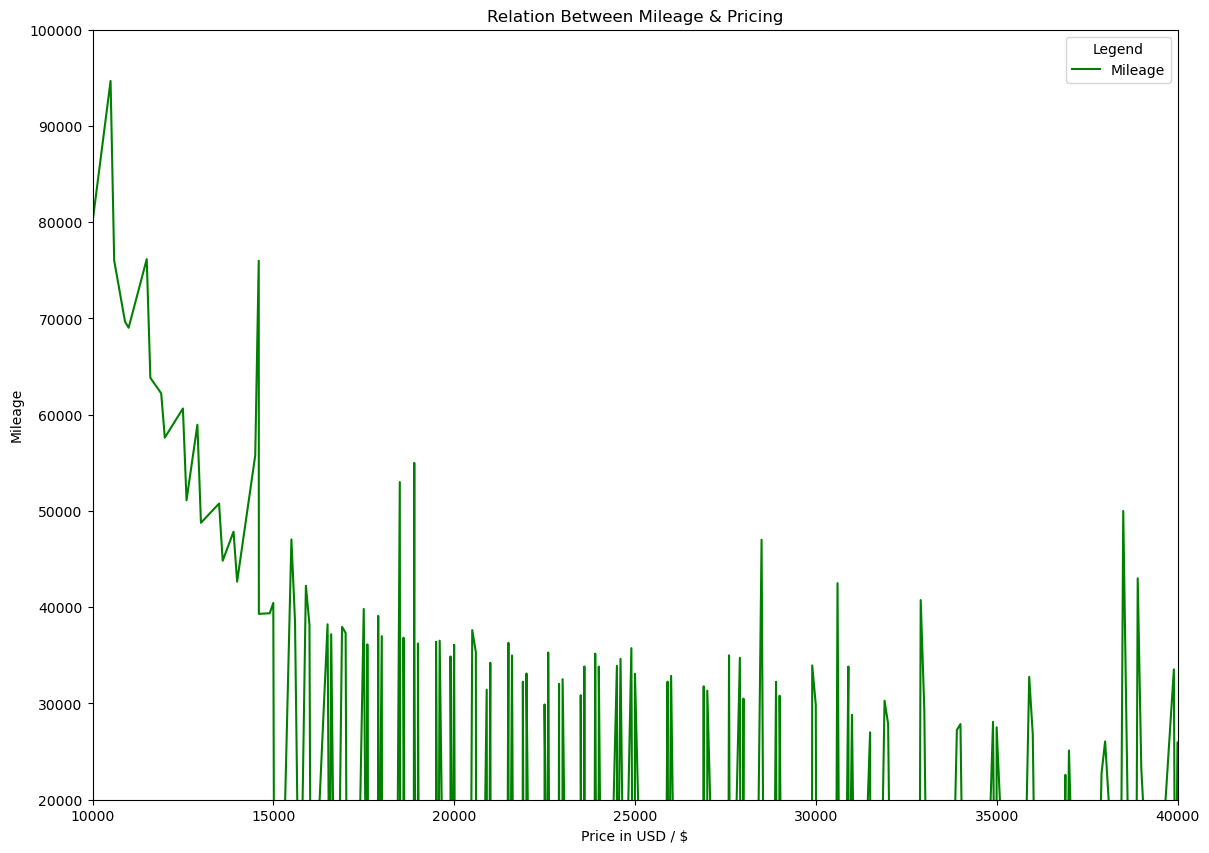

In [13]:
# Plot the means as a line graph. Why Mean? Because there may be many values of the same price with different
# Mileage or vice versa
means = df.groupby('Price')['Mileage'].mean()

# Here we want to shrink the size of the graph as it was too big without adding this code in
fig, ax = plt.subplots(figsize=(14, 10))

# This line is to draw a line representing the mean of "Mileage"
means.plot(kind='line', ax=ax, color="g")

# Add a legend and labels to clarify the graph
ax.set_title("Relation Between Mileage & Pricing")
ax.legend(title='Legend', loc='upper right')
ax.set_xlabel("Price in USD / $")
ax.set_ylabel("Mileage")

# Set the limits of the x-axis. If we did not do this the graph would be too jittered due to how large the dataset
# is.
ax.set_xlim([10000, 40000])
ax.set_ylim([20000, 100000])

# Show the plot
plt.show()

__________________________________________________________________________________________________________

Here we can see as the as the mileage decreases the price increases meaning they are inversly proportional. It is obvious that a car that has exceeded 80,000 miles would cost less than a car that has only covered 10,000 miles. we can see that in the graph some cars cost more than others after $15000. This could be correct as the car model may be later than others, and this could play a role in setting prices for a car. the car brand/ Manufacturer and model could play a big role in car prices as well. Or... this could be because we have used the mean of the mileage which may have lead to less accurate results.

__________________________________________________________________________________________________________

Now lets make another graph to represent how many cars are on sale. we will do so with "Make" collumn and "Number of cars" collumn which we will make

In [14]:
df['Make'].value_counts()

Ford             12289
Nissan           10692
Chevrolet         9134
Toyota            8846
Honda             6991
Hyundai           6885
Dodge             5520
Kia               4333
Volkswagen        3837
Jeep              3416
Mercedes-Benz     3149
Chrysler          2933
BMW               2624
Lexus             2085
GMC               2062
Infiniti          2013
Mazda             1956
Buick             1657
Acura             1378
Audi              1129
Subaru             863
Cadillac           859
Lincoln            763
Scion              732
Mitsubishi         633
Fiat               619
Mini               559
Volvo              458
Land               401
Porsche            258
Saturn             205
Smart              190
Pontiac            184
Mercury            167
Jaguar             151
Hummer              28
Name: Make, dtype: int64

__________________________________________________________________________________________________________

We can refer to this table we have done earlier and plot this into a bar chart

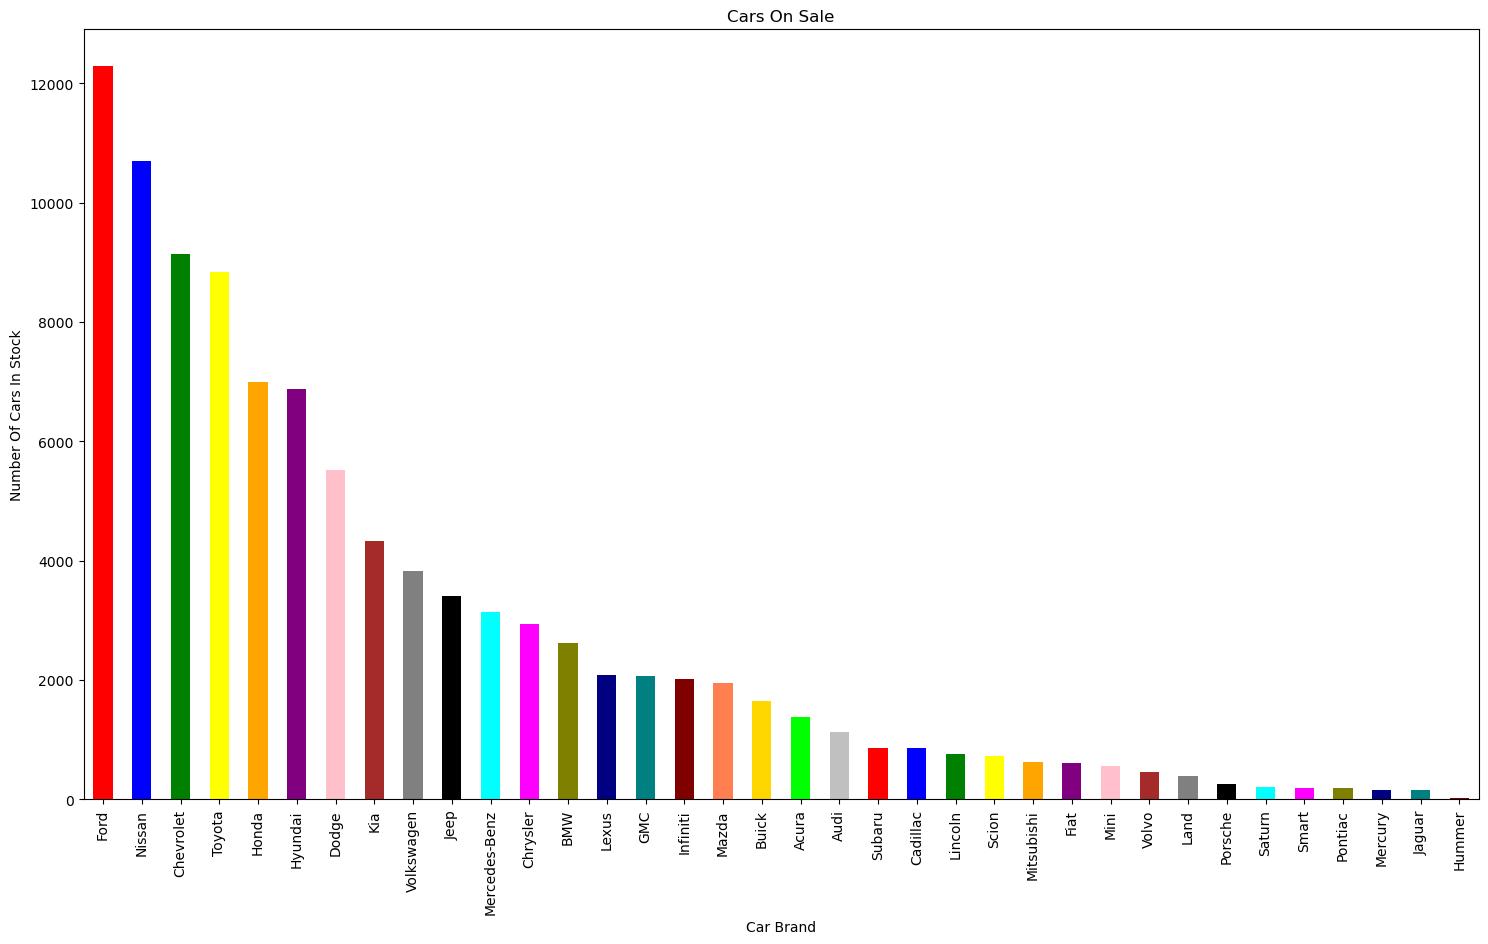

In [15]:
# Count the number of cars for each make
make_counts = df['Make'].value_counts()

colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'pink', 'brown', 'gray', 'black', 'cyan', 'magenta', 'olive', 'navy', 'teal', 'maroon', 'coral', 'gold', 'lime', 'silver']

fig, ax = plt.subplots(figsize=(18, 10))
ax = make_counts.plot(kind='bar', color=colors)

ax.set_xlabel('Car Brand')
ax.set_ylabel('Number Of Cars In Stock')
ax.set_title("Cars On Sale")

plt.show()

__________________________________________________________________________________________________________

We can see that Ford is the most car the car retailer has in stock. This could mean that that Ford is a popular car and many customers have used Ford. This means that the retailer should mainly focus on selling Ford cars. Now lets have a closer look at which Ford vehicle is the most in stock and compare their prices

In [16]:
ford_df = df[df['Make'] == 'Ford']
ford_model_counts = ford_df['Model'].value_counts()
print(ford_model_counts)

Focus SE             1590
Fusion SE             664
F150 XLT              580
Fiesta SE             561
Escape SE             512
                     ... 
Freestyle SEL           2
Focus ZTS               2
Freestyle Limited       1
E-250                   1
Explorer XLS            1
Name: Model, Length: 123, dtype: int64


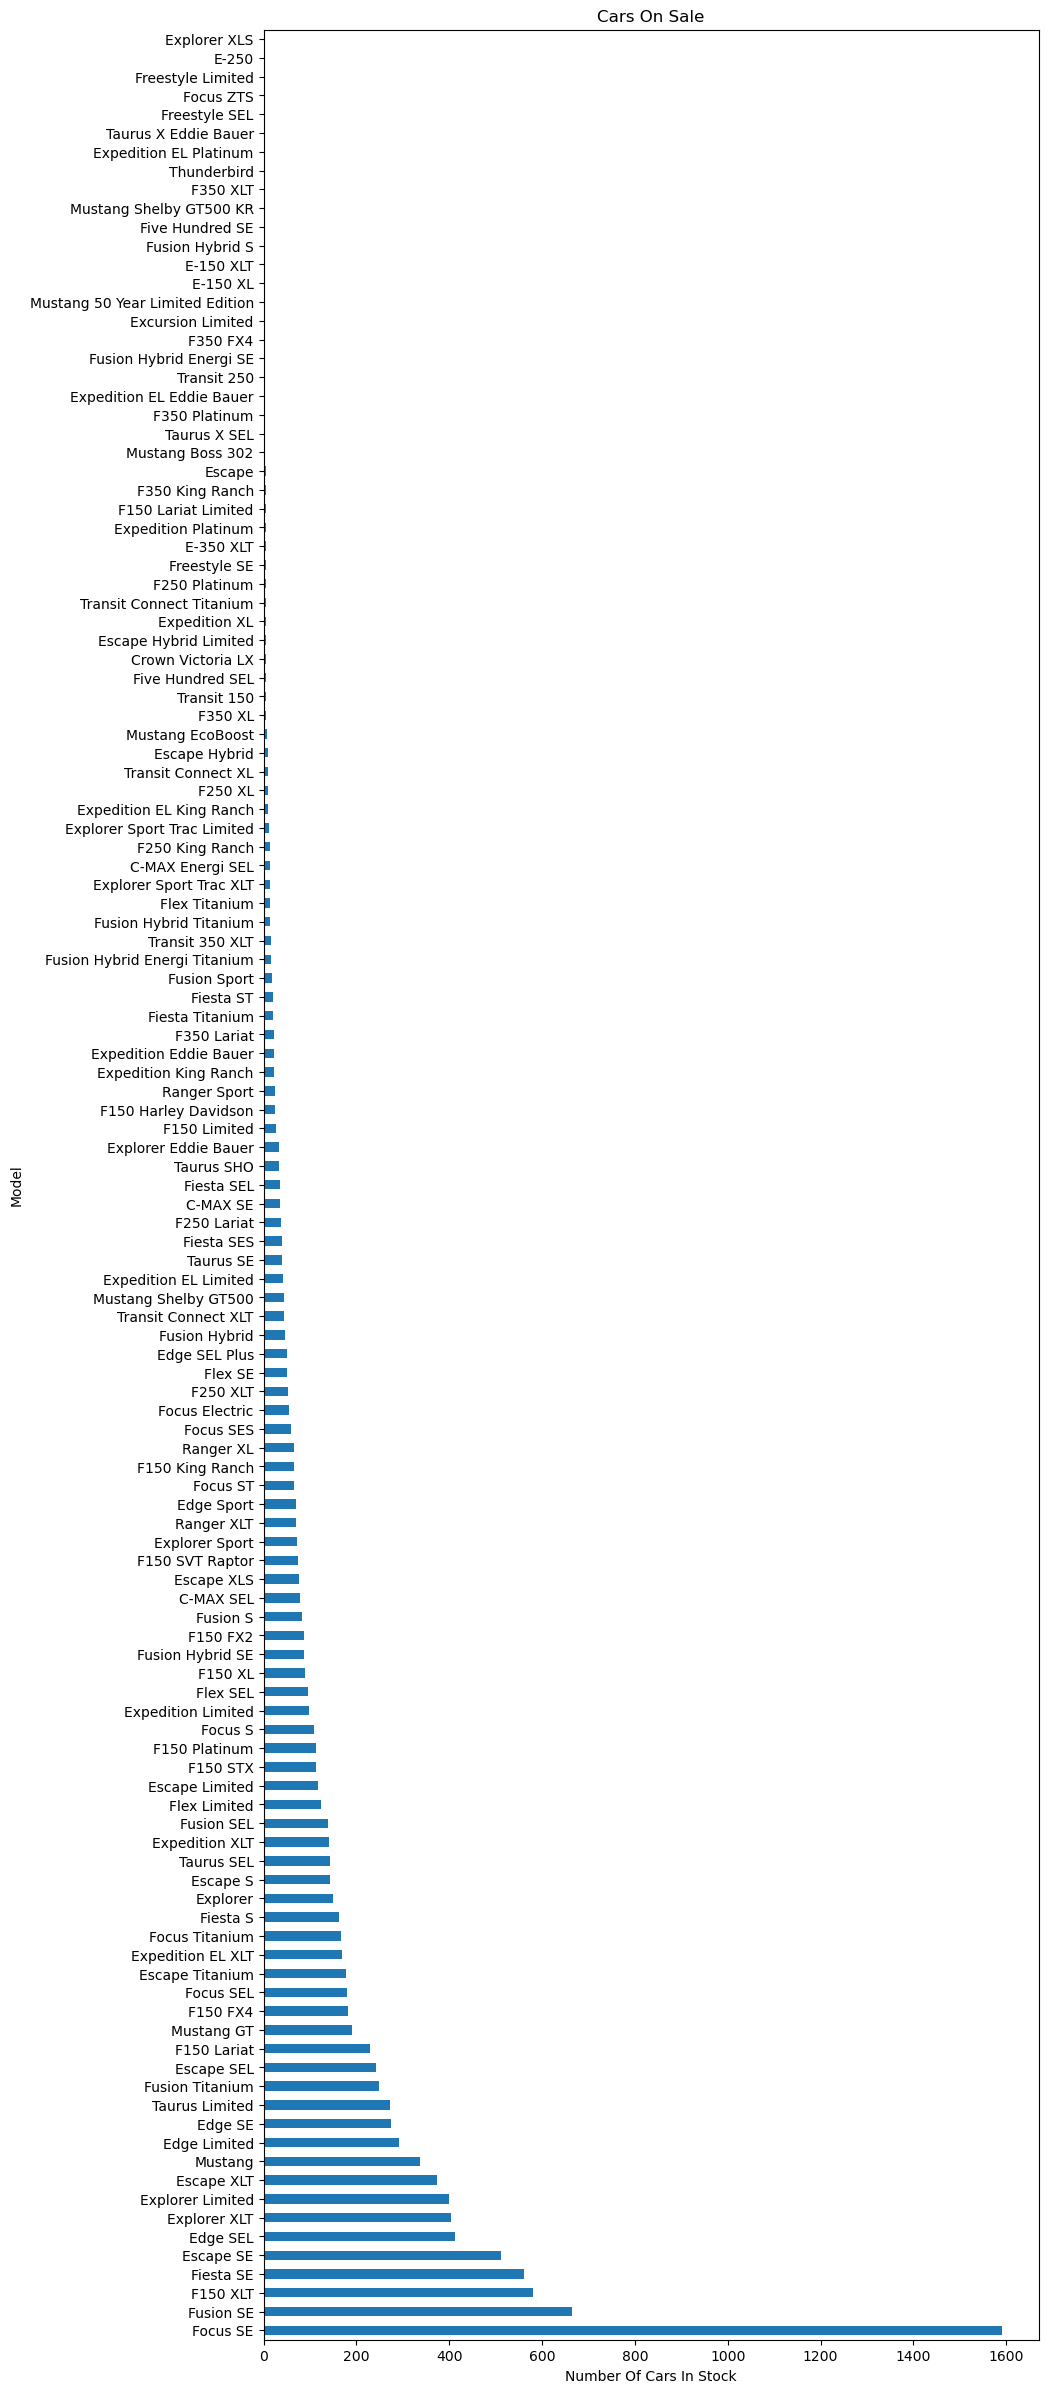

In [17]:
fig, ax = plt.subplots(figsize=(10, 30))
ax = ford_model_counts.plot(kind='barh')

ax.set_ylabel('Model')
ax.set_xlabel('Number Of Cars In Stock')
ax.set_title('Cars On Sale')

plt.show()

__________________________________________________________________________________________________________

Now lets find their price for each model

In [18]:
ford_df = df[df['Make'] == 'Ford']
ford_model_price = ford_df['Price']
print(ford_model_counts)

Focus SE             1590
Fusion SE             664
F150 XLT              580
Fiesta SE             561
Escape SE             512
                     ... 
Freestyle SEL           2
Focus ZTS               2
Freestyle Limited       1
E-250                   1
Explorer XLS            1
Name: Model, Length: 123, dtype: int64


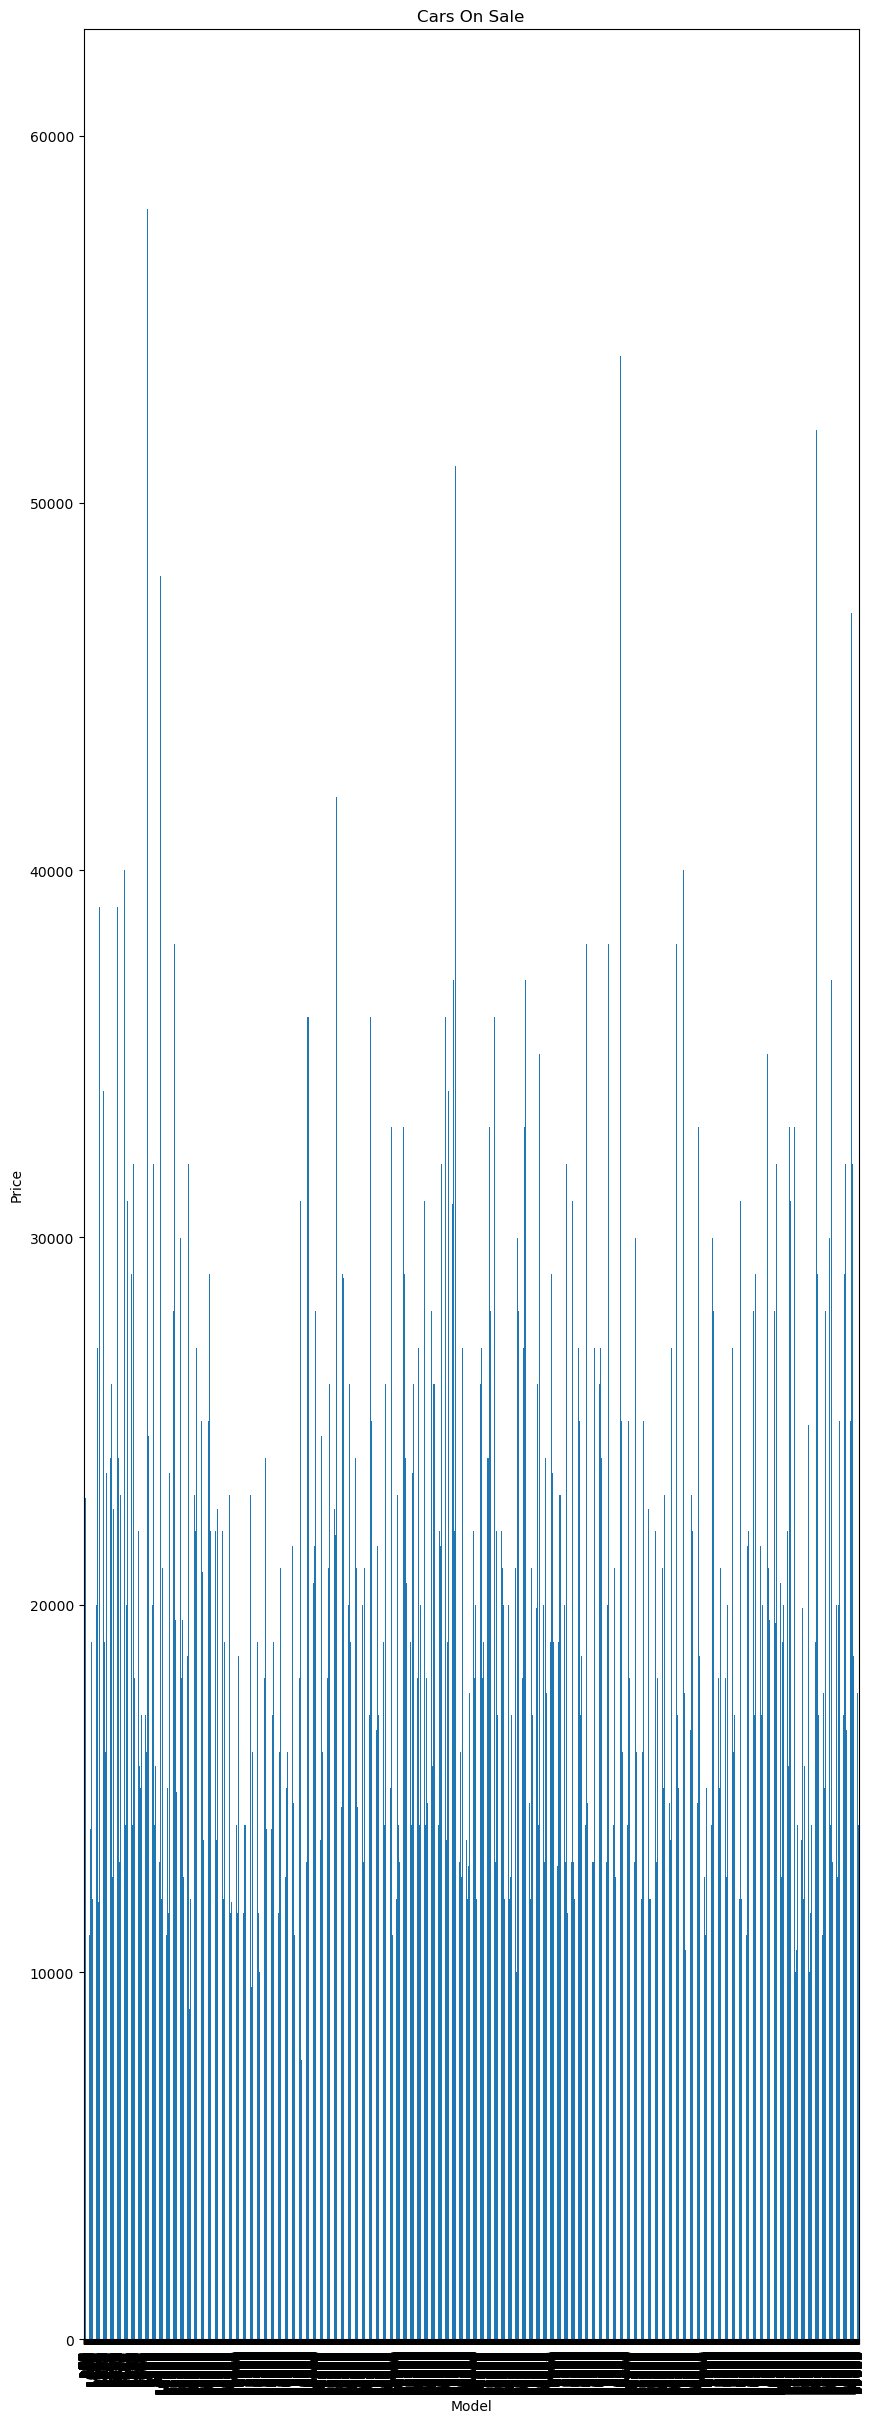

In [20]:
fig, ax = plt.subplots(figsize=(10, 30))
ax = ford_model_price.plot(kind='bar')

ax.set_xlabel('Model')
ax.set_ylabel('Price')
ax.set_title('Cars On Sale')

plt.show()